# 경제 분석 및 예측과 데이터 지능 실습 3.2: VAR 모델링

이 노트북은 `practice3_1`에서 다룬 전처리/집계 이후 단계입니다.  
여기서는 **모델링(VAR) 자체**에만 집중합니다.

## 범위

- OECD 분기 거시 데이터 로드
- 국가 1개 선택 후 다변량 시계열 구성
- 정상성 점검(ADF)
- 로그 차분 후 VAR 시차 선택/적합
- 안정성/Granger 인과/IRF/FEVD 확인
- 다분기 예측

References:
- [Vector Autoregression with Statsmodels](https://www.statsmodels.org/stable/vector_ar.html)
- [Sims (1980)](https://www.jstor.org/stable/1912017)
- [Blanchard and Quah (1989)](https://uh.edu/~bsorense/BlanchardQuah1989.pdf)

## 0) 데이터/변수 선택

이번 실습에서는 저장된 파일 `../datasets/querterly_oecd_account_data.csv`를 사용합니다.

### 변수 선택 기준

- `Y`: GDP
- `C`: Consumption
- `I`: Investment

필요하면 `EX`, `IM`, `G`를 추가해 차원을 확장할 수 있지만, 첫 VAR 실습은 2~3변수부터 시작하는 것이 안정적입니다.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)

In [2]:
df_oecd = pd.read_csv("../datasets/querterly_oecd_account_data.csv")
df_oecd["date"] = pd.to_datetime(df_oecd["date"])

print("shape:", df_oecd.shape)
print("countries:", sorted(df_oecd["country"].unique()))
print("date range:", df_oecd["date"].min().date(), "~", df_oecd["date"].max().date())

display(df_oecd.head())

shape: (1515, 8)
countries: ['CAN', 'DEU', 'FRA', 'GBR', 'IND', 'IRL', 'ITA', 'JPN', 'KOR', 'MEX', 'USA']
date range: 1990-01-01 ~ 2024-10-01


,country,date,Y,C,G,I,EX,IM
0,CAN,1990-01-01,1015714.7,518707.4,271355.6,223461.1,207736.8,200021.9
1,DEU,1990-01-01,3220806.5,1811014.8,569128.8,725261.2,527153.8,489620.3
2,FRA,1990-01-01,2244890.8,1170205.4,554966.9,517196.6,352329.9,353194.4
3,GBR,1990-01-01,2038060.5,1141647.3,450827.1,404835.9,345478.9,331416.2
4,IRL,1990-01-01,99243.7,47489.0,21623.8,23005.3,29526.0,33508.4


## 1) 국가 선택과 다변량 시계열 구성

In [3]:
target_country = "KOR"
var_cols = ["Y", "C", "I"]

df_country = (
    df_oecd.loc[df_oecd["country"] == target_country, ["date"] + var_cols]
    .sort_values("date")
    .set_index("date")
)

# 분기 시작 주기(QS)로 인덱스 정합
# 일부 시점 누락이 있으면 NaN이 생기므로 아래에서 제거
qidx = pd.date_range(df_country.index.min(), df_country.index.max(), freq="QS")
df_country = df_country.reindex(qidx)
df_country.index.name = "date"

print(f"target_country: {target_country}")
print("before dropna:", df_country.shape)
print("missing rows:", int(df_country.isna().any(axis=1).sum()))

display(df_country.head())

target_country: KOR
before dropna: (140, 3)
missing rows: 0


,Y,C,I
date,,,
1990-01-01,574706.9,364524.3,215160.4
1990-04-01,587662.4,372525.7,222357.8
1990-07-01,608487.6,380417.5,238732.4
1990-10-01,620089.4,388700.6,242593.6
1991-01-01,642776.3,395142.2,251889.0


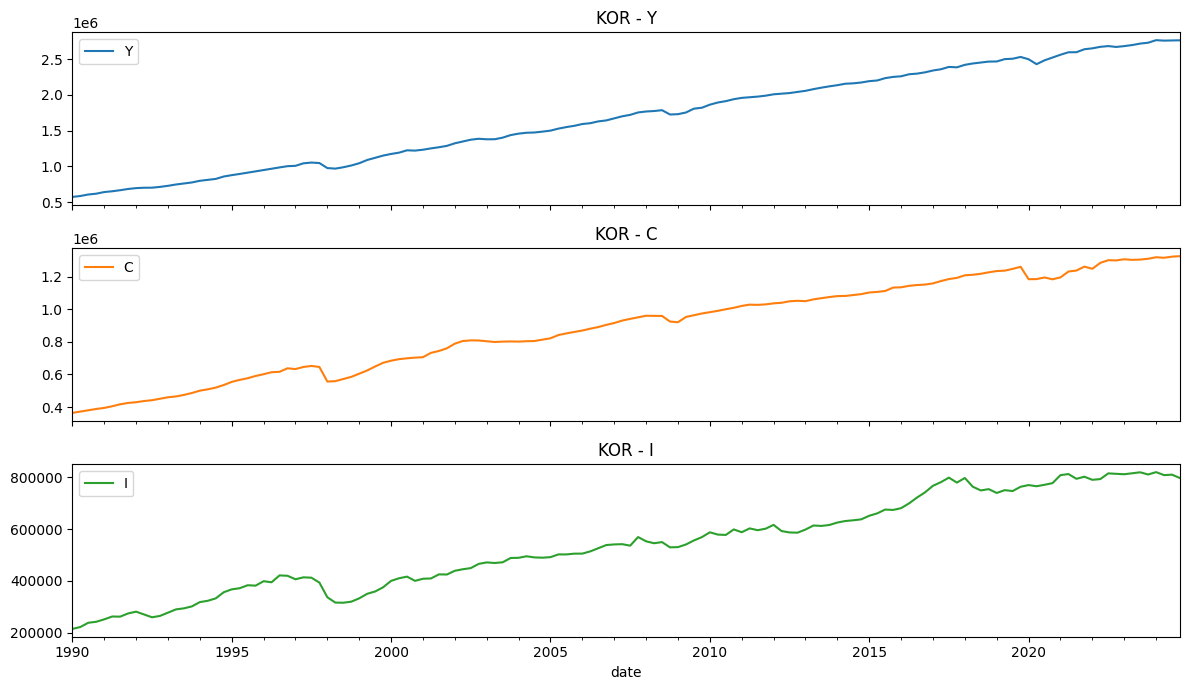

In [4]:
# 수준(level) 데이터 기본 플롯
ax = df_country[var_cols].plot(subplots=True, figsize=(12, 7), title=[f"{target_country} - {c}" for c in var_cols])
plt.tight_layout()
plt.show()

In [5]:
# ADF 테스트 유틸리티

def adf_report(df_in: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for col in df_in.columns:
        s = df_in[col].dropna()
        stat, pval, lags, nobs, _, _ = adfuller(s, autolag="AIC")
        rows.append({
            "variable": col,
            "adf_stat": stat,
            "p_value": pval,
            "used_lags": lags,
            "nobs": nobs,
            "stationary_5pct": pval < 0.05,
        })
    return pd.DataFrame(rows)

level_adf = adf_report(df_country[var_cols].dropna())
print("[ADF on level data]")
display(level_adf)

[ADF on level data]


,variable,adf_stat,p_value,used_lags,nobs,stationary_5pct
0,Y,-0.278779,0.928457,6,133,False
1,C,-1.134838,0.700981,1,138,False
2,I,-0.975671,0.762034,2,137,False


## 2) 정상성 확보: 로그 1차 차분

In [6]:
df_level = df_country[var_cols].dropna().copy()
df_logdiff = np.log(df_level).diff().dropna()

print("level shape:", df_level.shape)
print("logdiff shape:", df_logdiff.shape)

logdiff_adf = adf_report(df_logdiff)
print("[ADF on log-diff data]")
display(logdiff_adf)

level shape: (140, 3)
logdiff shape: (139, 3)
[ADF on log-diff data]


,variable,adf_stat,p_value,used_lags,nobs,stationary_5pct
0,Y,-7.530422,3.590808e-11,0,138,True
1,C,-9.024716,5.650805e-15,0,138,True
2,I,-6.504621,1.139312e-08,1,137,True


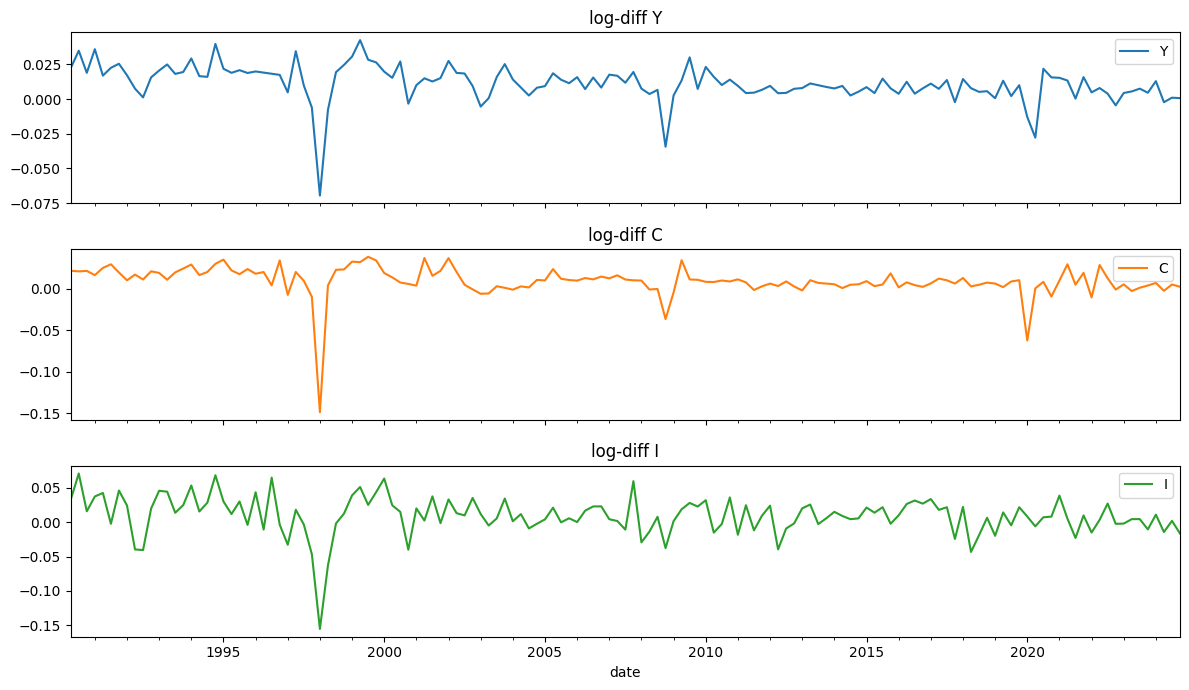

In [7]:
ax = df_logdiff.plot(subplots=True, figsize=(12, 7), title=[f"log-diff {c}" for c in var_cols])
plt.tight_layout()
plt.show()

In [8]:
# 상관구조 확인
print("[Correlation matrix of log-diff variables]")
display(df_logdiff.corr().round(3))

[Correlation matrix of log-diff variables]


,Y,C,I
Y,1.000,0.788,0.735
C,0.788,1.000,0.584
I,0.735,0.584,1.000


In [9]:
## 3) VAR 시차 선택과 모형 적합

# 정보기준 기반 시차 선택
var_model = VAR(df_logdiff)
lag_selection = var_model.select_order(maxlags=8)

print("[Lag order selection]")
print(lag_selection.summary())

# 실습용 기본: BIC 우선, 없으면 AIC 사용
selected_lag = lag_selection.selected_orders.get("bic")
if selected_lag is None:
    selected_lag = lag_selection.selected_orders.get("aic")
if selected_lag is None:
    selected_lag = 2

if selected_lag < 1:
    selected_lag = 1

print("selected_lag:", selected_lag)

var_res = var_model.fit(selected_lag)
print(var_res.summary())

[Lag order selection]
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -25.54     -25.47*   8.094e-12      -25.51
1     -25.70*      -25.43  6.926e-12*     -25.59*
2      -25.58      -25.12   7.747e-12      -25.40
3      -25.55      -24.89   7.994e-12      -25.29
4      -25.46      -24.61   8.766e-12      -25.11
5      -25.42      -24.37   9.117e-12      -25.00
6      -25.42      -24.17   9.167e-12      -24.91
7      -25.45      -24.00   8.960e-12      -24.86
8      -25.46      -23.82   8.880e-12      -24.79
-------------------------------------------------
selected_lag: 1
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 31, May, 2026
Time:                     21:35:44
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -25.4382

## 4) 진단: 안정성 및 Granger 인과성

모형 적합 후에는 최소한 아래를 확인해야 합니다.

- 안정성(stability): 모든 고유값이 단위원 안쪽인지
- Granger 인과성: 변수 간 예측력 관계가 통계적으로 유의한지

해석 주의:
- Granger 인과성은 구조적 인과관계의 증명과는 다릅니다.
- 데이터 생성과정/동시성/누락변수에 따라 해석이 달라질 수 있습니다.

$$
\begin{bmatrix}
c_{t} \\
y_{t}
\end{bmatrix}
=
\begin{bmatrix}
u_{1} \\
u_{2}
\end{bmatrix}
+
\begin{bmatrix}
\phi_{11}(1) & \phi_{12}(1) \\
\phi_{21}(1) & \phi_{22}(1)
\end{bmatrix}
\begin{bmatrix}
c_{t-1} \\
y_{t-1}
\end{bmatrix}
+
\begin{bmatrix}
\phi_{11}(2) & \phi_{12}(2) \\
\phi_{21}(2) & \phi_{22}(2)
\end{bmatrix}
\begin{bmatrix}
c_{t-2} \\
y_{t-2}
\end{bmatrix}
+
\begin{bmatrix}
\epsilon_{1t} \\
\epsilon_{2t}
\end{bmatrix}
$$
또는
$$
\bold{X}_{t} = \mu + \Phi(1) \bold{X}_{t-1} + \Phi(2) \bold{X}_{t-2} + \Epsilon_{t}
$$

- 여기서 잔차항은 $\Epsilon_{t} \sim N(0, \Omega)$ 를 따르는 벡터입니다.
- 위 모형이 성립하려면 $| I - \Phi(1)Z - \Phi(2)Z^{2} | = 0$ 의 모든 해(solution)의 절대값이 1보다 커야 합니다.
- 이러한 정상성(stationarity) 가정은 eigenvalue(고유값)의 가장 큰 값이 1보다 작다는 말과 동일합니다.



### Lag Length(시차 길이)

1. **Lag Length 결정의 중요성:**
   - VAR 모형의 시차(lag) 길이는 모형의 설명력과 예측 성능에 크게 영향을 미칩니다.
   - 너무 짧은 시차를 선택하면 모형에 중요한 동적 정보를 반영하지 못하고, 너무 긴 시차를 선택하면 모형 복잡성이 증가하고 불필요한 파라미터가 포함됩니다.

2. **통계적 검정 방법:**
   - **Wald Test(F-test):** 
     - F 통계량:
       $$
       F = \frac{(|\hat{\Omega}(H_{0})| - |\hat{\Omega}(H_{1})|) / J}{|\hat{\Omega}(H_{1})| / (T-k)}
       $$
   - **Likelihood Ratio Test(LR Test):** 
     - LR 통계량:
       $$
       LR = (T-k) \left( \log |\hat{\Omega}(H_{0})| - \log |\hat{\Omega}(H_{1})| \right) \sim \chi^{2}(J)
       $$
       - 여기서 $\hat{\Omega}(H_{0}) = \sum \hat{\epsilon}_{t}(H_{0})\hat{\epsilon}_{t}(H_{0})'$, $\hat{\Omega}(H_{1}) = \sum \hat{\epsilon}_{t}(H_{1})\hat{\epsilon}_{t}(H_{1})'$ 는 잔차 공분산 행렬을 의미합니다.
       - T는 표본 크기, k는 추정된 파라미터의 수, 그리고 J는 제약 조건의 수를 의미합니다.
       - 또한 $\hat{\epsilon}_{t} = \bold{X}_{t} - \hat{\mu} - \Phi(1) \bold{X}_{t-1} - \Phi(2) \bold{X}_{t-2} $ 이고 가설에 따라 $\Phi(1)$ 또는 $\Phi(2)$ 가 0이 됩니다.

3. **순차적 검정 방법(Sequential Test):**
   - 시차 길이 결정을 위해 순차적 검정 방법을 사용하여, 한 단계씩 추가하면서 모형의 적합도를 평가합니다.
   - 각 단계에서 추가된 시차가 통계적으로 유의한지 여부를 평가하고, 유의하지 않은 경우 시차 길이를 결정하게 됩니다.
   - 이러한 검정 방법은 Wald test나 LR test를 기반으로 하며, 큰 표본에서는 두 검정의 결과가 동일하게 나타나는 경향이 있습니다.
   - 예를 들어, LR 검정 통계량과 J * F (F 통계량을 chi-square 분포로 변환한 통계량)은 큰 표본 환경에서 동등한 결과를 보입니다.


### Granger Causality Test

   - 위 모형에서 y가 c를 GC(Granger Cause)하지 '않는다'는 다음과 같이 검정할 수 있습니다.
   $$
   H_{0} : \phi_{12}(1) =\phi_{12}(2) = 0
   $$

   - 마찬가지로, c가 y를 GC하지 '않는다'는 것은 다음과 같이 검정합니다.
   $$
   H_{0} : \phi_{21}(1) =\phi_{21}(2) = 0
   $$

   - Test statistic은 아래와 같습니다.
   $$
   F = \frac{(RSS_{0} - RSS_{1})/J}{RSS_{1}/(T-k)} \quad \sim \quad F(T-k)
   $$




#### 아래 코드에서 확인할 항목

1. `var_res.is_stable()`
2. 역근(inverse roots) 크기
3. `Y -> C`, `C -> I`, `I -> Y` Granger 검정 결과

각 검정의 p-value를 보고 유의수준 5% 기준으로 해석하세요.

In [10]:
print("is stable:", var_res.is_stable())
print("inverse roots abs:", np.round(np.abs(var_res.roots), 4))

pairs = [("C", ["Y"]), ("I", ["C"]), ("Y", ["I"])]
for caused, causing in pairs:
    res_gc = var_res.test_causality(caused=caused, causing=causing, kind="wald")
    print(f"{causing} -> {caused}: p-value={res_gc.pvalue:.4f}")


is stable: True
inverse roots abs: [9.6873 4.587  2.4381]
['Y'] -> C: p-value=0.1511
['C'] -> I: p-value=0.0449
['I'] -> Y: p-value=0.9896


## 5) 동태 해석: IRF와 FEVD

- IRF(Impulse Response Function): 한 변수 충격이 다른 변수에 미치는 시차별 반응
- FEVD(Forecast Error Variance Decomposition): 예측오차 분산에서 각 충격의 기여 비중

여기서는 12분기(3년) horizon 기준으로 확인합니다.

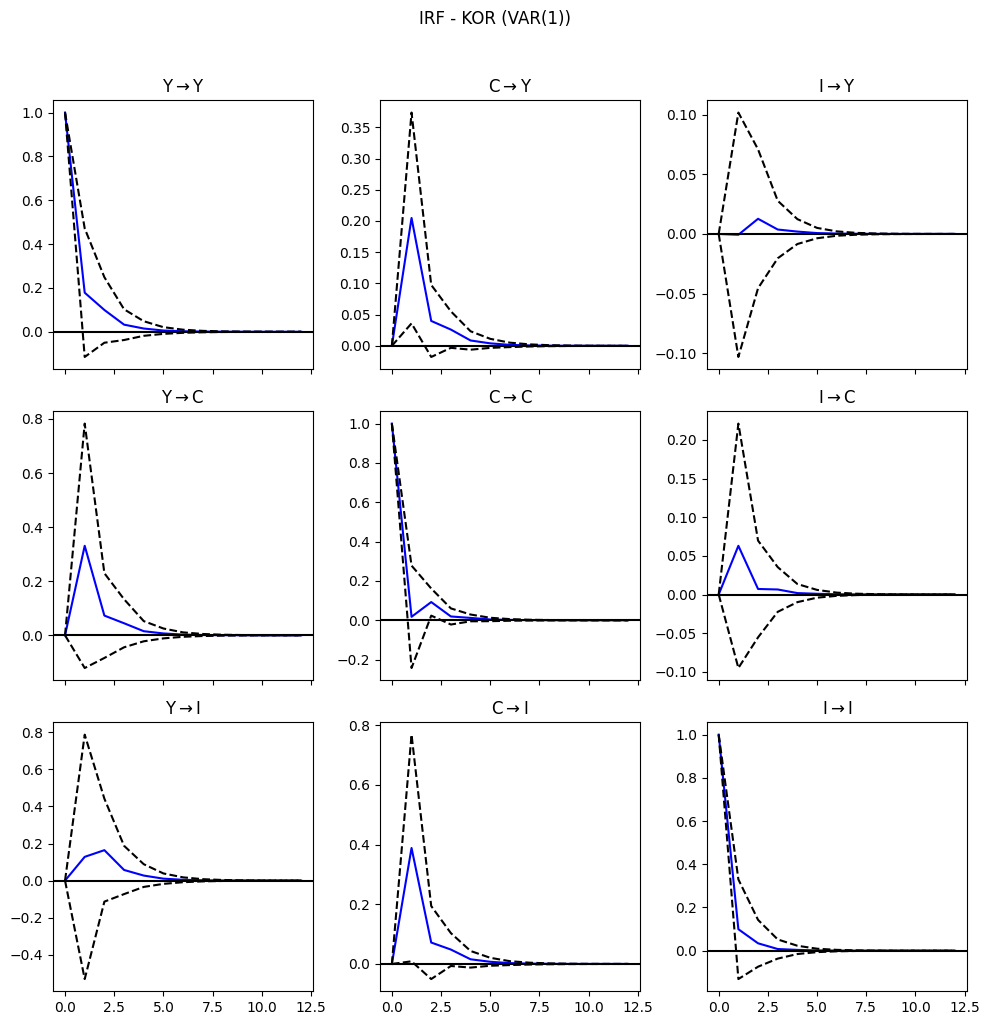

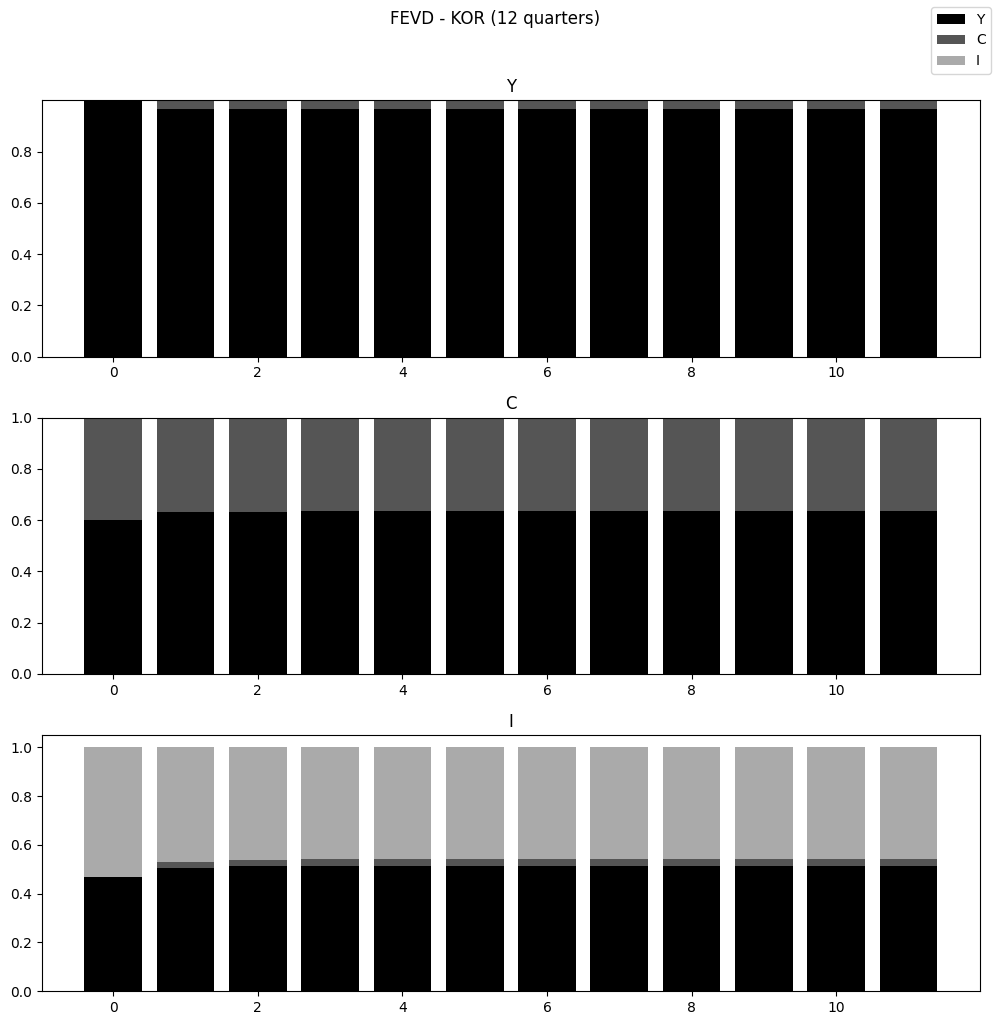

In [11]:
# -------------------------------------------------------------------
irf = var_res.irf(12)
irf.plot(orth=False)
plt.suptitle(f"IRF - {target_country} (VAR({selected_lag}))", y=1.02)
plt.tight_layout()
plt.show()

fevd = var_res.fevd(12)
fevd.plot()
plt.suptitle(f"FEVD - {target_country} (12 quarters)", y=1.02)
plt.tight_layout()
plt.show()

In [12]:
h = 8  # 8분기 예측
lagged_values = df_logdiff.values[-selected_lag:]

forecast_vals = var_res.forecast(y=lagged_values, steps=h)
forecast_index = pd.date_range(df_logdiff.index[-1] + pd.offsets.QuarterBegin(), periods=h, freq="QS")
forecast_df = pd.DataFrame(forecast_vals, index=forecast_index, columns=[f"{c}_forecast" for c in var_cols])

print("[Forecast (log-diff scale)]")
display(forecast_df)

[Forecast (log-diff scale)]


,Y_forecast,C_forecast,I_forecast
2025-01-01,0.007899,0.003900,0.002603
2025-04-01,0.009486,0.007510,0.005992
2025-07-01,0.010506,0.008312,0.007935
2025-10-01,0.010851,0.008786,0.008571
2026-01-01,0.011009,0.008949,0.008863
2026-04-01,0.011070,0.009023,0.008975
2026-07-01,0.011096,0.009051,0.009023
2026-10-01,0.011107,0.009063,0.009042


## Appendix

구조적 VAR(SVAR), sign restriction, 식별 가정(Cholesky ordering)으로 확장 가능합니다.

### Eigenvalue, 정상성, 특성방정식, 단위원(Unit Circle), 로그 1차 차분

1. **Eigenvalue(고유값)와 정상성:**
   - VAR 모형의 안정성(stability)은 모형에 사용된 행렬들의 고유값에 의해 결정됩니다.
   - 구체적으로, 모형의 모든 고유값의 절대값이 1 미만일 경우, 모형은 정상(stationary)으로 간주됩니다.
   - 이는 VAR 모형이 장기적으로 수렴(convergence)하며, 충격(shock)이 시간이 지남에 따라 소멸됨을 의미합니다.

2. **특성방정식(Characteristic Equation):**
   - 예를 들어, VAR(2) 모형에서는 특성방정식이 다음과 같이 주어집니다:
     $$
     \left| I - \Phi(1)Z - \Phi(2)Z^{2} \right| = 0
     $$
   - 이 방정식의 해(즉, \( Z \)에 대한 해)는 모형의 동적 특성을 결정하며, 각 해의 절대값은 모형의 안정성에 직접적인 영향을 미칩니다.

3. **Unit Circle(단위원):**
   - Unit circle는 복소평면에서 반지름이 1인 원을 의미합니다.
   - VAR 모형의 안정성 판별 시, 특성방정식의 모든 고유값이 단위원 밖(즉, 절대값이 1보다 큰 영역)에 위치해야 합니다.
   - 실제로, 모형의 모든 고유값의 절대값이 1 미만이면(즉, 단위원 내부에 있으면) 모형은 정상(stationary)하지 않으며, 외부에 위치하면 정상성을 만족합니다.

4. **Log First Differencing (로그 1차 차분):**
   - 로그 1차 차분은 시계열 데이터의 각 시점 값에 로그를 취한 후, 인접한 시점 간의 차이를 계산하는 방법입니다.
   - 수식으로 표현하면, $\Delta \log X_t = \log(X_t) - \log(X_{t-1})$ 와 같이 계산되며, 이는 작은 변화에 대해 $\frac{X_t - X_{t-1}}{X_{t-1}}$ 로 근사될 수 있습니다.
   - 이 변환은 데이터의 상대적 변화, 즉 성장률 또는 비율 변화를 나타내며, 특히 경제나 금융 데이터를 분석할 때 유용합니다.
   - 로그 1차 차분은 다음과 같은 효과를 가집니다:
     - **비정상성 제거:** 수준(levels)의 시계열 데이터는 일반적으로 추세나 단위근(unit root) 문제로 인해 비정상(non-stationary)일 수 있는데, 로그 1차 차분을 통해 이러한 비정상성을 완화할 수 있습니다.
     - **분산 안정화:** 로그 변환을 사용하면 큰 값과 작은 값 사이의 스케일 차이가 줄어들어 분산이 안정화됩니다.
     - **해석 용이성:** 로그 1차 차분은 직접적으로 성장률(또는 비율 변화)을 반영하므로, 변수들 간의 상호작용이나 동적 변화를 해석하는 데 직관적인 장점을 제공합니다.
